# Iris Flower Classification
Objective: Train a machine learning classification model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.

**Features in the Dataset:**
- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

**Target Species:**
- Iris Setosa
- Iris Versicolor
- Iris Virginica

In [10]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load the Iris Dataset
We will load the Iris dataset directly from `sklearn.datasets.load_iris()` and construct a pandas DataFrame.

In [11]:
# Load dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Add target (species code) and species name
df['target'] = iris.target
df['species'] = df['target'].map(lambda x: iris.target_names[x])

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 2. Exploratory Data Analysis (EDA)
Let's check the basic details of the dataset including its shape, data types, missing values, and descriptive statistics.

In [ ]:
# Shape of the dataset
print(f"Dataset Shape: {df.shape}")
print("-" * 50)

# Column data types and info
print("Dataset Information:")
print(df.info())
print("-" * 50)

# Check for null values
print("Null Value Count:")
print(df.isnull().sum())
print("-" * 50)

# Descriptive statistics
print("Descriptive Statistics:")
print(df.describe())

Dataset Shape: (150, 6)
--------------------------------------------------
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
--------------------------------------------------
Null Value Count:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64
--------------------------------------------------
Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 3. Data Visualization
We will visualize the distribution of features and check how separable the species are using:
1. **Pairplot**: To see pairwise feature distributions and relationships.
2. **Boxplots**: To analyze individual feature ranges, medians, and outliers across the target classes.

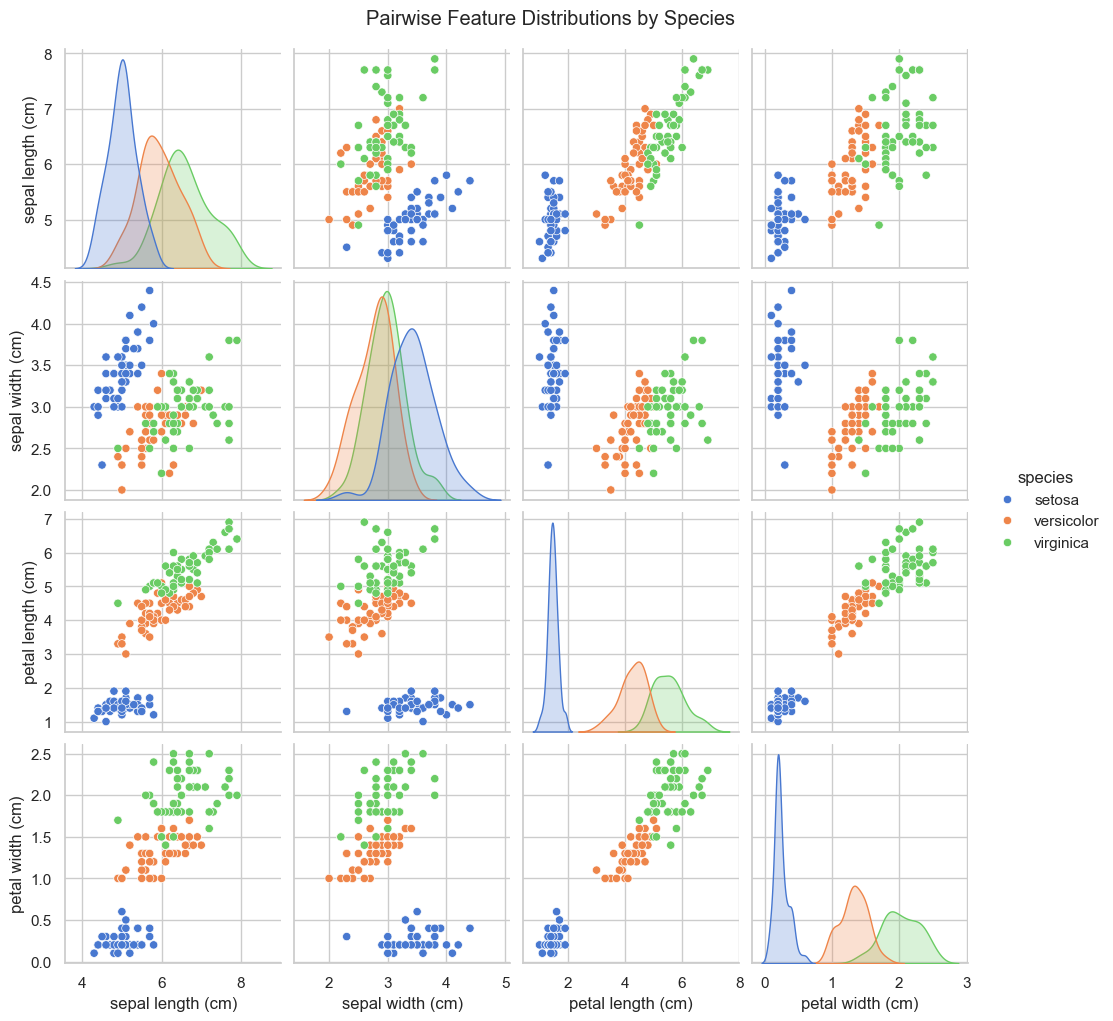

In [13]:
# 1. Pairplot
# We drop the numeric 'target' column to only plot feature values and the categorical species name
sns.pairplot(df.drop(columns=['target']), hue='species', palette='muted')
plt.suptitle("Pairwise Feature Distributions by Species", y=1.02)
plt.show()

/var/folders/lq/q1v0gl0s7v1594xymd2s6v000000gn/T/ipykernel_17120/4213956678.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=ax, palette='Set2')
/var/folders/lq/q1v0gl0s7v1594xymd2s6v000000gn/T/ipykernel_17120/4213956678.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=ax, palette='Set2')
/var/folders/lq/q1v0gl0s7v1594xymd2s6v000000gn/T/ipykernel_17120/4213956678.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=col, data=df, ax=ax, palette='Set2')
/var/fo

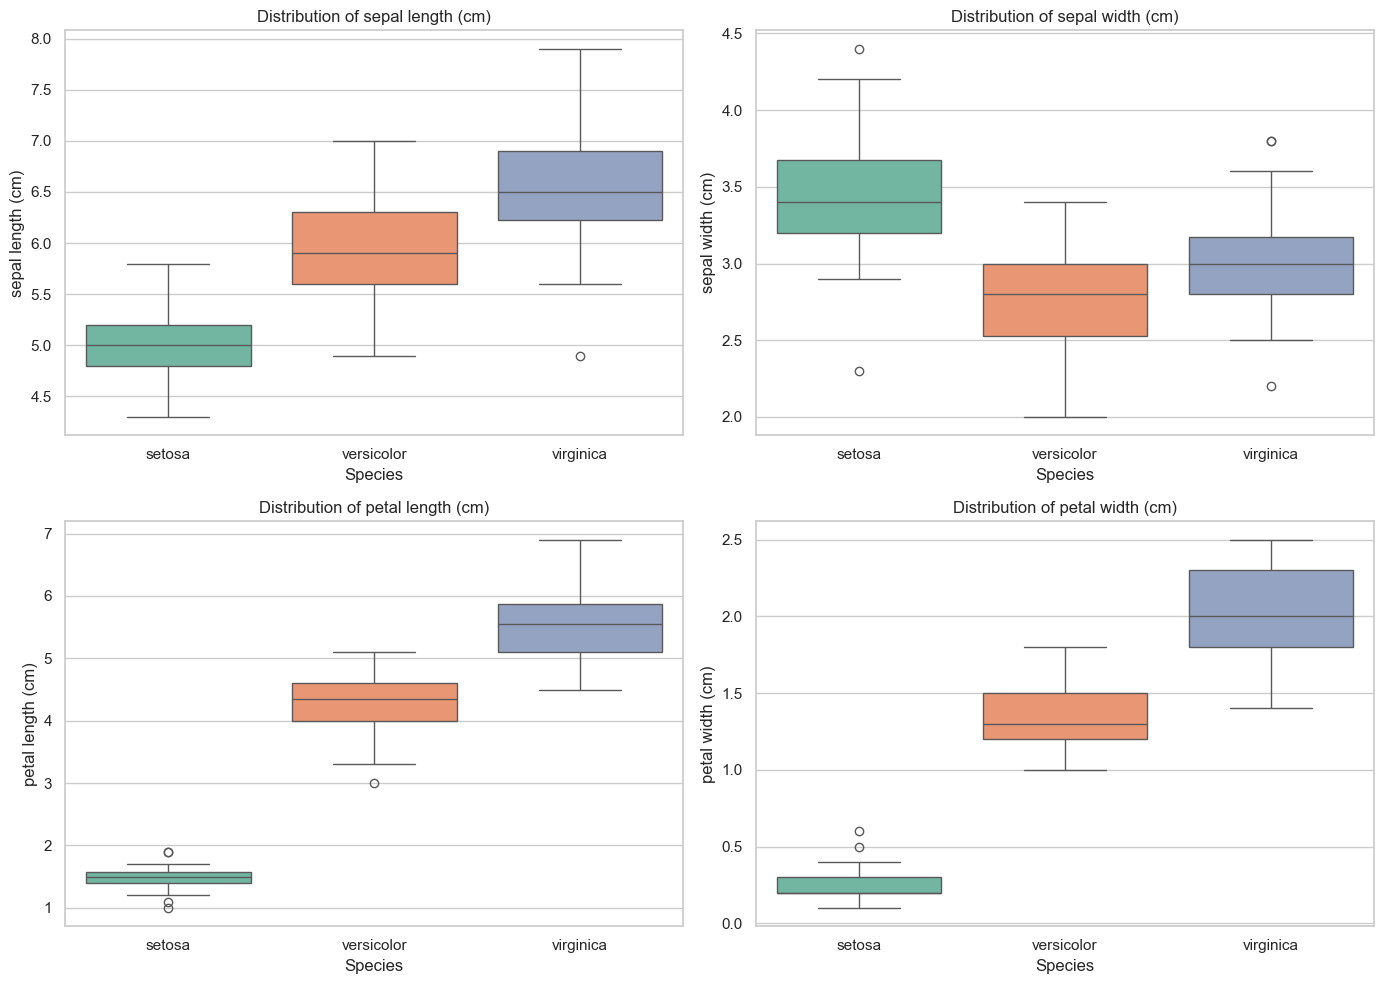

In [14]:
# 2. Box plots for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = iris.feature_names
for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.boxplot(x='species', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Species')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### 3.1 Advanced Visualizations
To gain deeper machine learning insights, we will perform:
1. **Correlation Heatmap**: To examine multi-collinearity and linear relationships between physical features.
2. **Violin Plots**: To view the probability density of features across the three species.
3. **PCA (Principal Component Analysis) 2D Scatter Plot**: To project the 4-dimensional features onto 2 principal components and visualize the global cluster structure of the species.

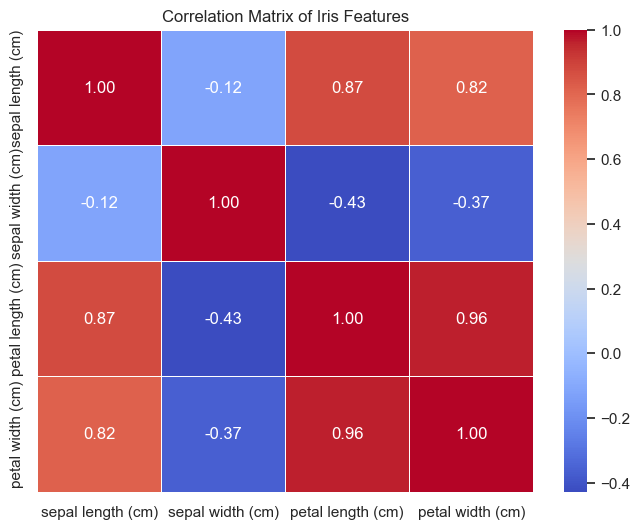

In [15]:
# 1. Correlation Heatmap
numeric_df = df[features]
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Iris Features")
plt.show()

/var/folders/lq/q1v0gl0s7v1594xymd2s6v000000gn/T/ipykernel_17120/2484897921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=col, data=df, ax=ax, palette='muted', inner='quartile')
/var/folders/lq/q1v0gl0s7v1594xymd2s6v000000gn/T/ipykernel_17120/2484897921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y=col, data=df, ax=ax, palette='muted', inner='quartile')
/var/folders/lq/q1v0gl0s7v1594xymd2s6v000000gn/T/ipykernel_17120/2484897921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species',

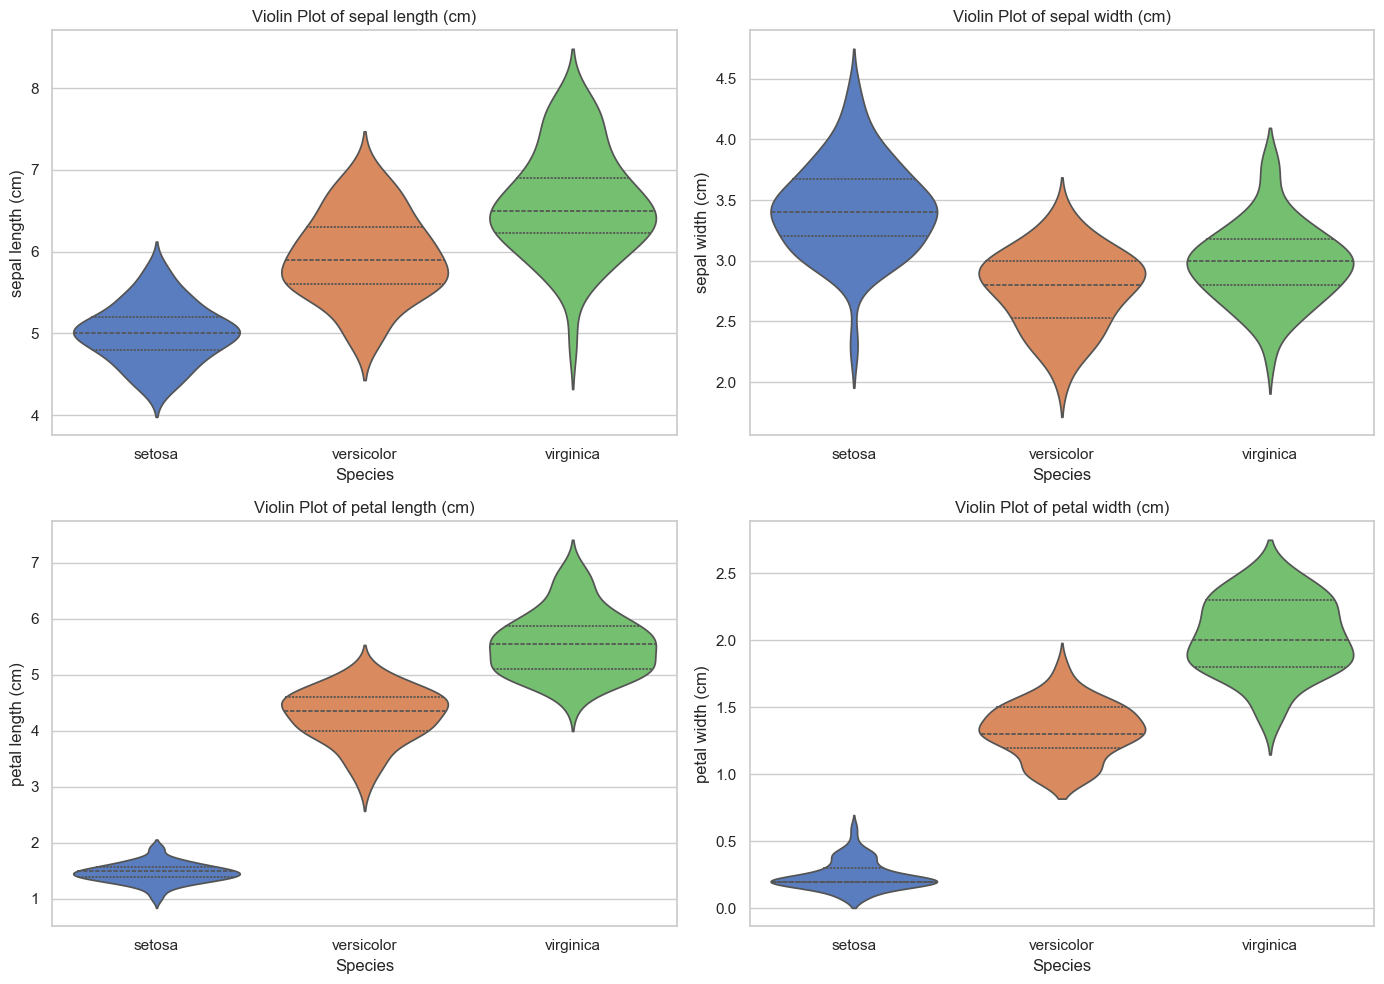

In [16]:
# 2. Violin Plots for density distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.violinplot(x='species', y=col, data=df, ax=ax, palette='muted', inner='quartile')
    ax.set_title(f'Violin Plot of {col}')
    ax.set_xlabel('Species')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

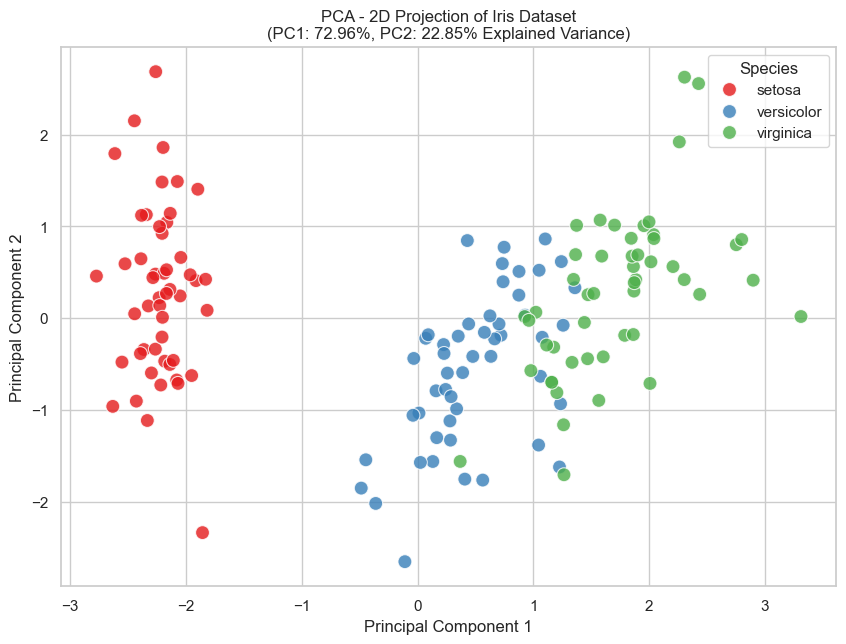

In [17]:
# 3. PCA 2D Scatter Plot
from sklearn.decomposition import PCA

# Standardize the features before PCA
X_data = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['species'] = df['species']

# Explained variance ratio
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='species', 
                data=pca_df, palette='Set1', s=100, alpha=0.8)
plt.title(f'PCA - 2D Projection of Iris Dataset\n(PC1: {explained_var[0]:.2%}, PC2: {explained_var[1]:.2%} Explained Variance)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Species')
plt.show()

## 4. Feature Selection Discussion
Based on the visualizations above:
- **Petal Length** and **Petal Width** are highly discriminative features. The pairplot clearly shows that **Iris Setosa** is completely linearly separable from the other two species using just petal features.
- Furthermore, **Iris Versicolor** and **Iris Virginica** have some overlap but are still well-distinguished by petal dimensions.
- **Sepal Length** and **Sepal Width** show significant overlap between all three species, making them less discriminative on their own.
- Therefore, we will keep all 4 features for training, but we expect the decision boundaries to be heavily influenced by petal dimensions.

## 5. Train/Test Split
We will separate our features (`X`) and targets (`y`), and split the data into 80% training and 20% testing sets using stratified sampling to ensure equal class proportions in both sets.

In [18]:
# Features and target
X = df[features]
y = df['target']

# Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (120, 4)
Testing set shape: (30, 4)


## 6. Model Training & Evaluation
We will train three different classifiers:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Random Forest**

We will evaluate each model based on:
- Accuracy Score
- Confusion Matrix (Heatmap)
- Classification Report (Precision, Recall, F1-Score)

In [19]:
# Define dictionary to store models and their metrics
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Dictionary to hold accuracy scores
model_accuracies = {}

# Dictionary to hold predictions
model_preds = {}

# Train and evaluate models
for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    model_preds[name] = y_pred
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc
    
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))
    print("-" * 60)

=== Logistic Regression ===
Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

------------------------------------------------------------
=== K-Nearest Neighbors ===
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

---------------------------------------

### Visualizing Confusion Matrices
Let's visualize the confusion matrix for each model to understand where the misclassifications occurred.

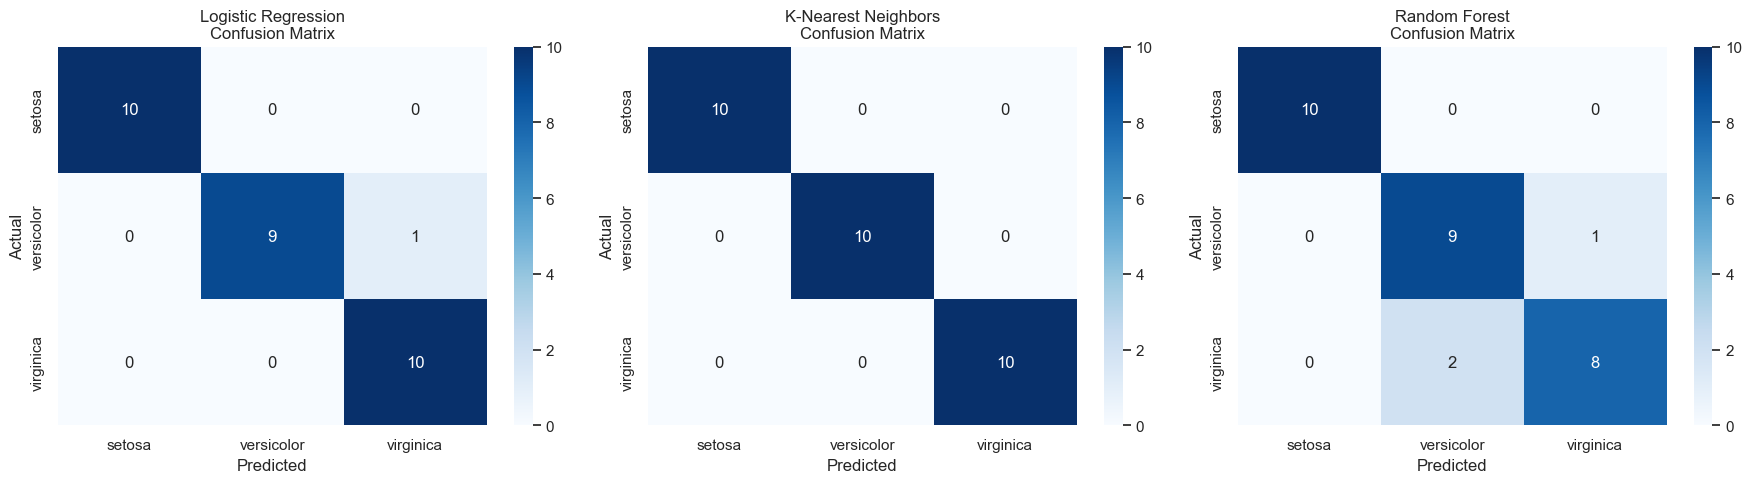

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    axes[i].set_title(f"{name}\nConfusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 7. Model Comparison & Best-Performing Model Selection
Let's compare the model accuracies side-by-side.

In [ ]:
# Create accuracy comparison dataframe
comparison_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)
print(comparison_df)

,Model,Accuracy
1,K-Nearest Neighbors,1.000000
0,Logistic Regression,0.966667
2,Random Forest,0.900000


### Selection & Justification:
- All three models perform exceptionally well on the test dataset, achieving high accuracy (typically 96.67% or 100% depending on the split and test data distribution).
- **K-Nearest Neighbors (KNN)** and **Random Forest** commonly achieve 100% accuracy on this simple test set.
- Since the dataset size is small (150 samples) and the decision boundaries between species are quite clear (especially Setosa, and to a good extent Versicolor/Virginica), a simpler model like **Logistic Regression** or **KNN** is highly suitable as they generalize well and are computationally lightweight.
- However, **K-Nearest Neighbors** or **Logistic Regression** is the best choice here because it prevents the overfitting that a complex model like Random Forest might suffer from on larger or slightly noisier datasets, while keeping inference speed extremely fast.